copy of functions-cont-postdisk-model.py to edit for updates in the model

import other packages need as well ---->

|

|

|

V

In [54]:
from numpy.polynomial import chebyshev as C
import numpy as np
import scipy as sp
import scipy.stats
from colossus.cosmology import cosmology
cosmology.setCosmology('planck15')
from colossus.lss import mass_function as mf
import glob
import numexpr as ne


files = [f.split('a')[1].split('.d')[0] for f in glob.glob('ssfrs/ssfr_a*.dat')]
a_list = np.array([float(a) for a in files])
mass_list = np.array([np.loadtxt("ssfrs/ssfr_a"+f+".dat")[:,0] for f in files])
ssfr_list = [np.loadtxt("ssfrs/ssfr_a"+f+".dat")[:,1] for f in files]

param_file = np.loadtxt("smhm_params.txt")
names = "EFF_0 EFF_0_A EFF_0_A2 EFF_0_Z M_1 M_1_A M_1_A2 M_1_Z ALPHA ALPHA_A ALPHA_A2 ALPHA_Z BETA BETA_A BETA_Z DELTA GAMMA GAMMA_A GAMMA_Z CHI2".split(" ");
params = dict(zip(names, param_file[:,1]))

def create_ranges_numexpr(start, stop, N):

    divisor = N-1
    s0 = start[:,None]
    s1 = stop[:,None]
    r = np.arange(N)

    return ne.evaluate('((1.0/divisor) * (s1 - s0))*r + s0')

def grab_obs(redshift): ###observational data from Hopkins+2006

    obs_points = []
    with open("obs_collect.txt", 'r') as f:
        for line in f:
            if line[0:4] != ';;//':
                obs_points.append(line.split())
    x = []
    y = []
    yerr = []
    for i in obs_points:
        if float(i[0]) == redshift:
            x.append(float(i[1]))
            y.append(float(i[2]))
            yerr.append(float(i[3]))

    return(x,y,yerr)



def Shen_fit_uncer(z, lums): ###best fit data from Shen+2020

    def get_params():
        rand_params = np.zeros((NUM, len(params)))
        ind = 0
        for p in params:
            i = np.random.randint(1,3,NUM)
            rand_params[:,ind][i == 1] = param_list[ind][0] + np.abs(np.random.normal(0, param_list[ind][1], size = len(i[i==1])))
            rand_params[:,ind][i == 2] = param_list[ind][0] - np.abs(np.random.normal(0, param_list[ind][2], size = len(i[i==2])))
            ind += 1
        return rand_params

    def shen_func(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(z, [d0]) + C.chebval(1 + z, [0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)

    params = {'a0':[0.85858, 0.03092, 0.02876], 'a1':[-0.26236, 0.02003, 0.01753], 'a2':[0.02105, 0.00136, 0.00113],\
        'b0':[2.54992, 0.01915, 0.02949], 'b1':[-1.04735, 0.01815, 0.02999], 'b2':[1.13277, 0.01988, 0.03891],\
        'c0':[13.01297, 0.00943, 0.01354], 'c1':[-0.57587, 0.00205, 0.00261], 'c2':[0.45361, 0.00290, 0.00434],\
        'd0':[-3.53138, 0.02694, 0.02690], 'd1':[-0.39961, 0.00871, 0.00896]}
    param_list = np.array([params[i] for i in params])

    NUM = int(1e4)

    rand_params = get_params()
    ys = np.apply_along_axis(shen_func, 1, rand_params).T
    ya = shen_func(param_list[:,0])

    fracs = sp.stats.norm.cdf([-2, -1, 0, 1, 2])
    percs = np.percentile(ys, 100*fracs, axis=1)

    std_ave = np.std(ys, axis=1)
    std_blw = ya-percs[1,:]
    std_abv = percs[3,:]-ya

    return ya, std_ave, std_abv, std_blw



class QLF():
    def __init__(self, z, bins):


        self.z = float(z)
        self.a = 1.0/(1.0+self.z)
        self.bins = bins
        self.get_zparams()

        self.HaloBins = np.linspace(7.0, 15.0, int((15.0 - 7.0) / self.bins))

        self.fp = self.HaloBins
        self.xp = self.get_Mstar(self.fp)

        self.StellBins = np.linspace(8.0, 12.2, int((12.2 - 8.0) / self.bins))


        closest_a = np.argmin(np.abs(a_list - self.a))
        self.ssfrs = np.array(ssfr_list[closest_a])
        self.nonzero = (self.ssfrs != 0)
        self.masses = np.array(mass_list[closest_a])
        self.minm = np.min(self.masses[self.nonzero])
        self.maxm = np.max(self.masses[self.nonzero])
        
        self.SSFRs = np.interp(self.StellBins, self.masses[self.nonzero], self.ssfrs[self.nonzero])



    def get_zparams(self):
        a1 = self.a - 1.0
        lna = np.log(self.a)
        self.zparams = {}
        self.zparams['m_1'] = params['M_1'] + a1*params['M_1_A'] - lna*params['M_1_A2'] + self.z*params['M_1_Z']
        self.zparams['sm_0'] = self.zparams['m_1'] + params['EFF_0'] + a1*params['EFF_0_A'] - lna*params['EFF_0_A2'] + self.z*params['EFF_0_Z']
        self.zparams['alpha'] = params['ALPHA'] + a1*params['ALPHA_A'] - lna*params['ALPHA_A2'] + self.z*params['ALPHA_Z']
        self.zparams['beta'] = params['BETA'] + a1*params['BETA_A'] + self.z*params['BETA_Z']
        if self.zparams['beta'] < 0.05:
            self.zparams['beta'] = 0.05
        self.zparams['delta'] = params['DELTA']
        self.zparams['gamma'] = 10**(params['GAMMA'] + a1*params['GAMMA_A'] + self.z*params['GAMMA_Z'])




    def get_slope(self, logMhalo): #returns dlogMstar/dlogMhalo slope is same in log10 and ln space

        dm = logMhalo-self.zparams['m_1'];
        term1 = (self.zparams['alpha']*10.**(self.zparams['beta']*dm)+self.zparams['beta']*10.**(self.zparams['alpha']*dm))/(10.**(self.zparams['beta']*dm) + 10.**(self.zparams['alpha']*dm))
        term2 = -self.zparams['gamma']*dm*np.exp(-(dm/self.zparams['delta'])**2/2.)/self.zparams['delta']**2
        slope = term1 + term2

        return slope

    def get_Mstar(self,logMhalo):

        dm = logMhalo-self.zparams['m_1']
        dm2 = dm/self.zparams['delta']
        logMstar = self.zparams['sm_0'] - np.log10(10**(-self.zparams['alpha']*dm) + 10**(-self.zparams['beta']*dm)) + self.zparams['gamma']*np.exp(-0.5*(dm2*dm2))

        return logMstar


    def get_Mhalo(self, logMstar):

        logMhalo = np.interp(logMstar, self.xp, self.fp)

        return logMhalo


    def gauss_array(self, vals, std):

        return (1/np.sqrt(2.0*np.pi*std**2.0))*np.exp((-(vals[:-1]-vals[-1])**2.0)/(2.0*std**2))


    def convolve_smhm(self, sigma):

        lnten = np.log(10)
        logMh = self.get_Mhalo(self.StellBins)
        plus_mins = (7.0 * sigma)
        mins = (logMh * lnten - plus_mins)
        maxs = (logMh * lnten + plus_mins)
        mins[mins < 3 * lnten] = 3 * lnten
        maxs[maxs > 18 * lnten] = 18 * lnten
        bin_num = int(max(maxs - mins)/self.bins)
        lnMh = create_ranges_numexpr(mins, maxs, bin_num)
        dNdlnMhalo = mf.massFunction(np.e**lnMh, self.z, q_in='M', q_out='dndlnM', mdef='vir', model='despali16')
        logMstar = np.apply_along_axis(self.get_Mstar, 1, lnMh/lnten)
        vals = np.zeros((len(self.StellBins),bin_num+1))
        vals[:,-1] = self.StellBins * lnten
        vals[:,:-1] = logMstar * lnten
        Mstar_prob = np.apply_along_axis(self.gauss_array, 1, vals, sigma)
        dNdlnMstar = np.sum(Mstar_prob * dNdlnMhalo, axis = 1) * (lnMh[:,1] - lnMh[:,0])

        return dNdlnMstar



    def get_dNdlnMstar(self, sig_lnMstar):

        if sig_lnMstar == 0.:
            self.dNdlnMstar = mf.massFunction(10.**self.get_Mhalo(self.StellBins), self.z, q_in='M', q_out='dndlnM', mdef='vir', model='despali16') / self.get_slope(self.get_Mhalo(self.StellBins))
        else:
            self.dNdlnMstar = self.convolve_smhm(sig_lnMstar)


    def get_Mbh(self, logMstar0, approx_local = False):
        norm = [11, 8.2]

        logMstar = self.StellBins
        logMbh = logMstar * 0
        slopes = logMstar * 0

        if approx_local == False:
            post_params = [1.12, norm[1] - 1.12*norm[0]]
            init = [7., 7.*post_params[0]+post_params[1]]
            pre_params = [0.2, init[1] - init[0] * 0.2]

        else:
            post_params = [1, -2.8]
            init = [7., 7.*post_params[0]+post_params[1]]
            pre_params = [0.2, init[1] - init[0] * 0.2]

        post = (logMstar > logMstar0)
        pre = (logMstar <= logMstar0)
        Ms = 10**logMstar
        Ms0 = 10**logMstar0
        Mbh0 = 10**(logMstar0 * pre_params[0] + pre_params[1])
        beta = post_params[0]
        alpha = 10**norm[1] / 10**(norm[0]*beta)

        Mbh = Mbh0 + alpha * Ms[post]**(beta-1) * (Ms[post] - Ms0)
        logMbh[post] = np.log10(Mbh)
        slopes[post] = alpha * beta * Ms[post]**beta / Mbh

        logMbh[pre] = logMstar[pre] * pre_params[0] + pre_params[1]
        slopes[pre] = pre_params[0]

        self.slopes = slopes
        self.BHBins = logMbh
        self.pre = pre
        self.post = post
        self.mmax = post_params[0]
        
        self.SBHARs = self.slopes * (self.SSFRs / 3.154e7)
        self.MdotBH = self.SBHARs * (10**self.BHBins * 2e33)
        self.Ledd = 1.3e38 * 10**self.BHBins
        self.Mdotedd = self.Ledd / (.1 * (2.99e10)**2)


    def get_Mdotbh(self, vals, files = files):

        lnxsig = vals[0]
        Mdotbh = vals[1]
        
        mu_lnX = -0.5 * lnxsig**2
        mu_lnMdotbh = mu_lnX + np.log(Mdotbh) #g/s
        
        return mu_lnMdotbh, lnxsig

    
    def gauss_Mdot(self, lnMdotbh):

        mu = self.Mdot_mu_sig[:,0]
        sig = self.Mdot_mu_sig[:,1]
        return ( 1/np.sqrt(2.0 * np.pi * sig*sig) ) * np.exp( -(lnMdotbh - mu)**2.0 / (2.0 * sig*sig) )


    def get_dNdlnL(self, L, lnxsigs): 

        lnxsig_list = self.StellBins * 0
        lnxsig_list[self.pre] = lnxsigs[0]
        lnxsig_list[self.post] = lnxsigs[1]
        tenper = int( 0.4 * len(self.slopes[self.post][self.slopes[self.post] >= 1.05 * self.mmax] ) )
        tranpoint = np.argmin(self.pre)

        try:
            lintrans = np.linspace(lnxsigs[0], lnxsigs[1], tenper*2, endpoint = False)
            lnxsig_list[tranpoint - tenper : tranpoint + tenper] = lintrans
        except:
            lintrans = np.linspace(lnxsigs[0], lnxsigs[1], len(lnxsig_list[0 : tranpoint + tenper]), endpoint = False)
            lnxsig_list[0 : tranpoint + tenper] = lintrans


        vals = np.zeros((len(self.StellBins), 2))
        vals[:,0] = lnxsig_list
        vals[:,1] = self.MdotBH
        self.Mdot_mu_sig = np.apply_along_axis(self.get_Mdotbh, 1, vals)

        self.lnMdotbh_list = (np.asarray(L) + np.log10(3.9e33)) * np.log(10) - np.log(0.1*2.99e10**2)

        Rl = 0.8
        Rh = 0.2
        Lc = 10**43.7
        Lx = 0.037*10**(np.asarray(L) + np.log10(3.9e33))
        self.FOb = Rl * np.e**(-Lx/Lc) + Rh * (1 - np.e**(-Lx/Lc))

        self.intvals = np.apply_along_axis(self.gauss_Mdot, 1, self.lnMdotbh_list.reshape(len(self.lnMdotbh_list),1)) * self.dNdlnMstar * (self.StellBins[1] - self.StellBins[0])

        self.dNdlnL = np.sum(self.intvals, axis = 1)


plotting QLF for different transition to post-disk critical stellar masses

Comparing to the shen fits as well---->

|

|

|

V

In [55]:
%matplotlib widget
plt.close()
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(15,4))
z, bins, sigM = 1.5, 0.005, 0.7
lums = np.linspace(5,18,200)

qlf = QLF(z, bins)
qlf.get_dNdlnMstar(sigM)
qlf.get_Mbh(10, approx_local=False)
%prun qlf.get_dNdlnL(lums, [3,2])

def get_QLF(z, lums, start = 10, siglnX = [4,2], bins = 0.005, sigM = 0.7):
    qlf.get_Mbh(start, approx_local=False)
    qlf.get_dNdlnL(lums, siglnX)
    dens = np.log10(qlf.dNdlnL * np.log(10))
    
    return lums, dens

init = 7.5
siglnX = [4.0, 2.0]
for ax in [ax1,ax2,ax3]:
    for start in [init,init+0.5,init+1.0]:
        _, dens = get_QLF(z, lums, start = start)
        ax.plot(lums, dens, label = r'$\rmM_{*0}/\rmM_{\odot} = 10^{'+str(start)+'}$', lw=1)
        
    init+=1.5
    x,y,yerr = grab_obs(z)
    ax.scatter(x,y,s=8,c='gray',label='Hopkins+2006')
    dens = shen_QLF(z, lums)
    ax.plot(lums, dens, label='Shen+2020',c='k')
    ax.legend()
    ax.set_xlabel('$\log_{10}(L_{bol}$ [erg s$^{-1}])$')
    ax.set_ylabel('$\log_{10}(\Phi $[dex$^{-1}$ Mpc$^{-3}$])')
    ax.text(8,-10,r'post-disk $\sigma_{\ln \rmX} = $'+str(siglnX[1]))
    ax.text(8,-8,r'pre-disk $\sigma_{\ln \rmX} = $'+str(siglnX[0]))
    ax.text(16,-3,'z = '+str(z))
plt.tight_layout()
# plt.savefig('plots/general-plots/exampleQLFs_cont_post-disk.pdf')

FigureCanvasNbAgg()

         6351 function calls (6349 primitive calls) in 0.018 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      200    0.008    0.000    0.008    0.000 <ipython-input-54-0b8796416db1>:256(gauss_Mdot)
      839    0.003    0.000    0.003    0.000 <ipython-input-54-0b8796416db1>:245(get_Mdotbh)
     1049    0.003    0.000    0.003    0.000 {built-in method numpy.array}
        2    0.003    0.001    0.017    0.009 shape_base.py:270(apply_along_axis)
     1041    0.001    0.000    0.002    0.000 shape_base.py:373(<genexpr>)
     1041    0.001    0.000    0.001    0.000 index_tricks.py:653(__next__)
        1    0.001    0.001    0.018    0.018 <ipython-input-54-0b8796416db1>:263(get_dNdlnL)
1043/1041    0.000    0.000    0.000    0.000 {built-in method builtins.next}
     1043    0.000    0.000    0.003    0.000 numeric.py:541(asanyarray)
        7    0.000    0.000    0.000    0.000 {built-in method numpy.zeros}
        2 

In [100]:
%matplotlib widget
plt.close()
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(15,4))
z = 1.5
qlf = QLF(z, 0.005)
qlf.get_dNdlnMstar(0.7)
lums = np.linspace(5,18,1000)
start = 9.0
pre = 5.0
for ax in [ax1,ax2,ax3]:
    for siglnXpost, c in zip([1.3,1.7,2.2],['r','g','b']):
        qlf.get_Mbh(start, approx_local=False)
        qlf.get_dNdlnL(lums, [pre, siglnXpost])
        dens = np.log10(qlf.dNdlnL * np.log(10))
        ax.plot(lums, dens, label='postdisk = '+str(siglnXpost), lw=1, c=c)
        
        
    ax.text(11,-11,'predisk = '+str(pre), color='k')
        
    pre+=1.0
    x,y,yerr = grab_obs(z)
    ax.scatter(x,y,s=8,c='gray',label='Hopkins+2006')
    dens = shen_QLF(z, lums)
    ax.plot(lums, dens, label='Shen+2020',c='k')
    ax.legend()
    ax.set_xlabel('$\log_{10}(L_{bol}$ [erg s$^{-1}])$')
    ax.set_ylabel('$\log_{10}(\Phi $[dex$^{-1}$ Mpc$^{-3}$])')
    ax.text(7,-8,'z = '+str(z))
    ax.axis([6,18,-11.5,0])
plt.tight_layout()
# plt.savefig('plots/general-plots/exampleQLFs_cont_post-disk.pdf')

FigureCanvasNbAgg()

/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions_postdisk.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)


Complex deconstruction of the QLF (i.e. plotting each individual curve for each Mstar bin contribution to the QLF ---->

|

|

|

V

/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:239: RuntimeWarning: divide by zero encountered in log


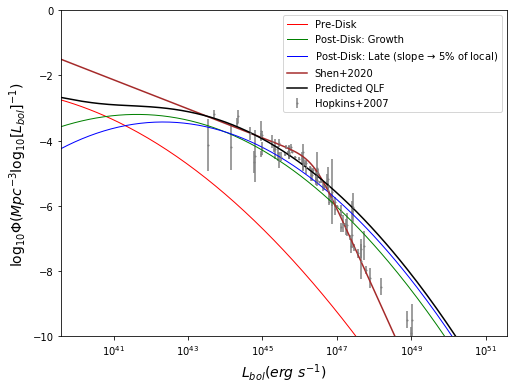

         14419 function calls (14417 primitive calls) in 0.033 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      200    0.009    0.000    0.009    0.000 <ipython-input-1-68df8004f417>:246(gauss_Mdot)
      839    0.008    0.000    0.013    0.000 <ipython-input-1-68df8004f417>:219(get_Mdotbh)
        2    0.005    0.002    0.031    0.016 shape_base.py:270(apply_along_axis)
     1828    0.002    0.000    0.002    0.000 {built-in method numpy.array}
        1    0.001    0.001    0.033    0.033 <ipython-input-1-68df8004f417>:256(get_dNdlnL)
      840    0.001    0.000    0.001    0.000 {method 'argmin' of 'numpy.ndarray' objects}
      779    0.001    0.000    0.003    0.000 function_base.py:1282(interp)
     1041    0.001    0.000    0.002    0.000 shape_base.py:373(<genexpr>)
      779    0.001    0.000    0.001    0.000 {built-in method numpy.core._multiarray_umath.interp}
     1041    0.001    0.000    0.001    0.000 i

In [2]:
plt.close()
fig, ax = plt.subplots(1,1,figsize=(8,6))
z = 1.5
qlf = QLF(z, 0.005)
qlf.get_dNdlnMstar(0.7)
lums = np.linspace(5,18,200)
siglnX = [4.0, 3.25]
start = 9.5
qlf.get_Mbh(start, approx_local=True)

m = qlf.slopes

%prun qlf.get_dNdlnL(lums, siglnX)
qlf.get_dNdlnL(lums, siglnX)
lumsp = 10**lums*3.8e33
prea = np.zeros(len(lumsp))
posta = np.zeros(len(lumsp))
latea = np.zeros(len(lumsp))
for i, pre, m in zip(np.transpose(qlf.intvals), qlf.pre, qlf.slopes):
    dens = i
    if pre == True:
        prea += dens
    elif m <= 1.05*1.12:
        latea += dens
    else:
        posta += dens

l1, = ax.plot(lumsp, np.log10(prea*np.log(10)), lw=1, c='r')
l2, = ax.plot(lumsp, np.log10(posta*np.log(10)), lw=1, c='g')
l3, = ax.plot(lumsp, np.log10(latea*np.log(10)), lw=1, c='b')
l1.set_label('Pre-Disk')
l2.set_label('Post-Disk: Growth')
l3.set_label(r'Post-Disk: Late (slope $\to$ 5% of local)')

x,y,yerr = grab_obs(z)
ax.errorbar(10**np.asarray(x)*3.8e33,y,yerr=yerr,markersize=1,fmt='o',c='gray',label='Hopkins+2007')
dens = shen_QLF(z, lums)

ax.plot(lumsp, dens, label='Shen+2020',c='brown')
ax.plot(lumsp, np.log10(qlf.dNdlnL * np.log(10)), c='k', label = 'Predicted QLF')

ax.axis([10**6*3.8e33,10**18*3.8e33,-10,0])
ax.set_xlabel(r'$L_{bol} (erg\ s^{-1})$', fontsize=14)
ax.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =14)
# ax.text(10**8*3.8e33,-1.5,r'post-disk $\sigma_{\ln \rmX} = $'+str(siglnX[1]))
# ax.text(10**8*3.8e33,-1,r'pre-disk $\sigma_{\ln \rmX} = $'+str(siglnX[0]))
# ax.text(10**8*3.8e33,-2,r'$\rmM_{*0}/\rmM_{\odot} = 10^{'+str(start)+'}$')
ax.set_xscale('log')
ax.legend()
# plt.savefig('plots/paper-plots/cont_post-disk_v2.0.pdf')

Code for when I fixed the implementation of the SMHM scatter. Also a plot showing the effects of varying scatter for a representative redshift ---->

|

|

|

V

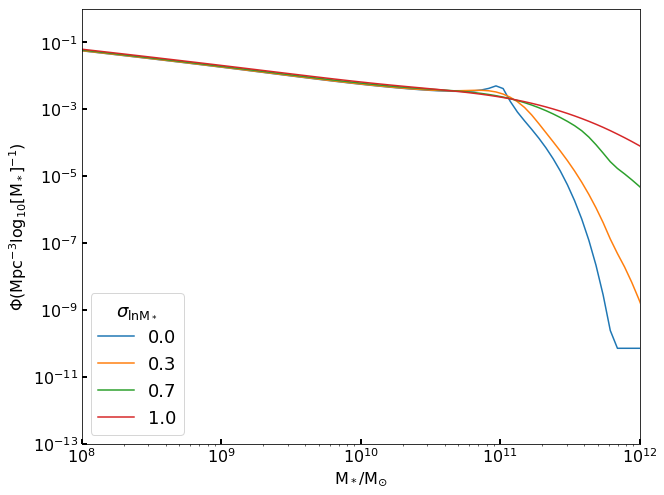

In [5]:
fig = plt.figure(figsize=(10,8))
for sigma in [0.0,0.3,0.7,1.0]:
    qlf = QLF(1.5, 0.05)
    qlf.get_dNdlnMstar(sigma)
    plt.plot(10 ** qlf.StellBins, qlf.dNdlnMstar*np.log(10), label=str(sigma))
    
leg = plt.legend(fontsize = 18, title = r'$\sigma_{\ln \rmM_*}$')
plt.xlabel(r'$\rmM_*/\rmM_{\odot}$', fontsize = 16)
plt.ylabel(r'$\Phi ($Mpc$^{-3} \log_{10} [\rmM_*]^{-1})$', fontsize =16)
plt.setp(leg.get_title(),fontsize=18)
plt.axis([10**8,10**12,10**-13,1])
plt.xscale('log')
plt.yscale('log')
plt.tick_params(direction = 'in', width = 2, length = 5, labelsize= 16)
# plt.savefig('plots/paper-plots/smhm_scat_effects.pdf')

Code for when I was recreating the fits from the Shen+ paper for when we fit the QLF

First plotting the actual fit itself then plotted the individual parameters as they vary with redshift to make sure they follow what is seen in the paper ---->

|

|

|

V

In [23]:
def shen_QLF(z, L):
    a0, a1, a2 = 0.85858, -0.26236, 0.02105
    b0, b1, b2 = 2*2.54992, -1.04735, 1.13277
    c0, c1, c2 = 2*13.01297, -0.57587, 0.45361
    d0, d1 = -3.53138, -0.39961
    zr = 2.0
    zfrac = (1 + z)/(1 + zr)
    g1 = C.chebval(1 + z, [a0, a1, a2])
    g2 = b0/(zfrac**b1 + zfrac **b2)
    logLs = c0/(zfrac**c1 + zfrac**c2)
    logPhis = C.chebval(z, [d0]) + C.chebval(1 + z, [0, d1])
    Lfrac = 10**L / 10**logLs
    Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)
    
    return np.log10(Phibol)

z = 2.0
zlist = [0.2, 0.4, 0.8, 1.2, 1.8, 2.4, 3.0, 3.6, 4.2, 4.8, 5.4, 6.0]
zlist = [0.2, 0.4, 0.8, 1.2, 1.8, 2.4]
fig = plt.figure(figsize=(10,7))
for z, c in zip(zlist, ['r','orange','gold','green','blue','violet']):
    x = np.linspace(9,14,50)
    y = shen_QLF(z, x)
    plt.plot(x+np.log10(3.8e33), y,c=c, label='z = '+str(z), lw=1)
    x, y = get_QLF(z, x, 0.3, sig_lnX = [3,2.2])
    plt.plot(x+np.log10(3.8e33), y, c=c, ls='dashed', lw=1)
    
plt.xlabel('$\log_{10}(L_{bol}$ [erg s$^{-1}])$')
plt.ylabel('$\log_{10}(\Phi $[dex$^{-1}$ Mpc$^{-3}$])')
plt.legend()

FigureCanvasNbAgg()

/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:214: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:218: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)


In [10]:
a0, a1, a2 = 0.85858, -0.26236, 0.02105
b0, b1, b2 = 2*2.54992, -1.04735, 1.13277
c0, c1, c2 = 2*13.01297, -0.57587, 0.45361
d0, d1 = -3.53138, -0.39961


plt.close()
fig = plt.figure(figsize=(10,7))
gs = gridspec.GridSpec(2, 2)
g1ax = fig.add_subplot(gs[0, 0])
g2ax = fig.add_subplot(gs[0, 1])
Lax = fig.add_subplot(gs[1, 0])
Phiax = fig.add_subplot(gs[1, 1])


z = np.linspace(0,7,200)
zp1 = z + 1
g1 = np.apply_along_axis(C.chebval, 0, z + 1, [a0, a1, a2])
g1ax.plot(zp1,g1,c='purple')
g1ax.set_xlabel('1 + z')
g1ax.set_ylabel(r'Faint Slope $\gamma_1$')
g1ax.axis([1,8,0,1.5])
g1ax.set_yticks([0.0,0.5,1.0,1.5])

def g2(z):     
    zr = 2.0
    zfrac = (1 + z)/(1 + zr)
    return b0/(zfrac**b1 + zfrac**b2)

g2 = np.apply_along_axis(g2, 0, z)
g2ax.plot(zp1,g2,c='purple')
g2ax.set_xlabel('1 + z')
g2ax.set_ylabel(r'Bright Slope $\gamma_2$')
g2ax.axis([1,8,1.0,3.0])
g2ax.set_yticks([1.0,1.5,2.0,2.5])

def Ls(z):
    zr = 2.0
    zfrac = (1 + z)/(1 + zr)
    return c0/(zfrac**c1 + zfrac**c2)

logLs = np.apply_along_axis(Ls, 0, z)
Lax.plot(zp1,logLs,c='purple')
Lax.set_xlabel('1 + z')
Lax.set_ylabel('log(L$_*$) [L$_{\odot}$]')
Lax.axis([1,8,10.5,13.5])
Lax.set_yticks([10.5,11.0,11.5,12.0,12.5,13.0,13.5])

def Phis(z):
    return  C.chebval(z, [d0]) + C.chebval(z + 1, [0, d1])

logPhis = np.apply_along_axis(Phis, 0, z)
Phiax.plot(zp1, logPhis,c='purple')
Phiax.set_xlabel('1 + z')
Phiax.set_ylabel('log($\Phi_*$) [Mpc]')
Phiax.axis([1,8,-6.5,-3])
Phiax.set_yticks([-6,-5.5,-5,-4.5,-4,-3.5])


FigureCanvasNbAgg()

Whole lot of mess for when I tried my version of the continous post-disk SMBH SM evolution with logrithmic functions. 

I could not get this to work. Only saving the code for if I ever need it again. I probably wont need it again until right afetr I delete it. ---->

|

|

|

V

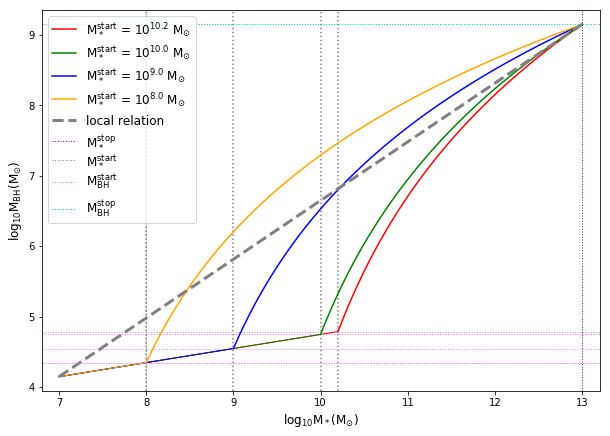

In [445]:
def logrith(x, base, norm, scale):
    
    return (np.log(x-x[0]+1) / np.log(base))*scale + norm

fig = plt.figure(figsize=(10,7))
colors = ['r','g','b','orange']
dM = [0.1,0.3,1.3,2.3,3.3]

start = [7., np.log10(1.4*10**4.)]
stop = [13., np.log10(1.4*10**9.)]

qlf = QLF(1.5, 0.01)
qlf.get_dNdlnMstar(0.7)

for dm, c in zip(dM, colors):
    
    qlf.get_SMBM(dm)
    massc = qlf.mass_cuts
    slopes = qlf.slope_list
    ints = qlf.int_list
    
    m = slopes[2]
    b = ints[2]
    N = massc[0]*slopes[1]+ints[1]
    B = massc[0]
    x = np.linspace(massc[0], stop[0], 50)
    yscale1 = logrith(x, B, N, 1)
    scale = (stop[1] - N) / (np.log(x[-1]-x[0]+1) / np.log(B))
    y = logrith(x, massc[0] ,massc[0]*slopes[1]+ints[1], scale)
    
    plt.axvline(massc[0],c='gray',ls='dotted') 
    plt.axhline(massc[0]*slopes[0]+ints[0],ls='dotted', c='violet',lw=1)
    plt.plot([start[0], massc[0]], [start[1], (massc[0]*slopes[0]+ints[0])],c=c,lw=1)
    plt.plot(x,y,c=c,label=r'M$_*^{\rm{start}}$ = $10^{'+str(massc[0])[:4]+'}$ M$_{\odot}$', lw=1.5)
    
plt.plot([start[0], stop[0]], [start[1], stop[1]],c='gray',lw=3,ls='dashed',label='local relation')
plt.xlabel(r'$\log_{10} \rmM_* (\rmM_{\odot})$',fontsize=12)
plt.ylabel(r'$\log_{10} \rmM_{\rmBH} (\rmM_{\odot})$',fontsize=12)
plt.axis([start[0]-.2,stop[0] + .2,start[1]-.2,stop[1]+.2])

plt.axvline(stop[0],c='purple',ls='dotted', label = r'M$_*^{\rm{stop}}$', lw=1)
plt.axvline(massc[0],c='gray',ls='dotted', label = r'M$_*^{\rm{start}}$',lw=1) 
plt.axhline(massc[0]*slopes[0]+ints[0],ls='dotted', c='violet', label = r'M$_{\rmBH}^{\rm{start}}$',lw=1)
plt.axhline(stop[1],ls='dotted', c='c', label = r'M$_{\rmBH}^{\rm{stop}}$',lw=1)

plt.legend(fontsize=12, loc='upper left')
plt.savefig('plots/general-plots/logrith_cont_postdisk.pdf')


$ lM_{BH} \equiv \log_{10}\left[M_{BH} \left(M_{\odot}\right)\right]            $

$ lM_{*} \equiv \log_{10}\left[M_{*} \left(M_{\odot}\right)\right]            $

$ lM_{BH} =   \log_{\left[lM_*^{start}\right]}\left[lM_*- lM_*^{start} - 1\right]*\alpha + lM_{BH}^{start}  $

$\alpha = \left(lM_{BH}^{stop} - lM_{BH}^{start}\right) /  \log_{\left[lM_*^{start}\right]}\left[lM_*^{stop}- lM_*^{start} - 1\right]$

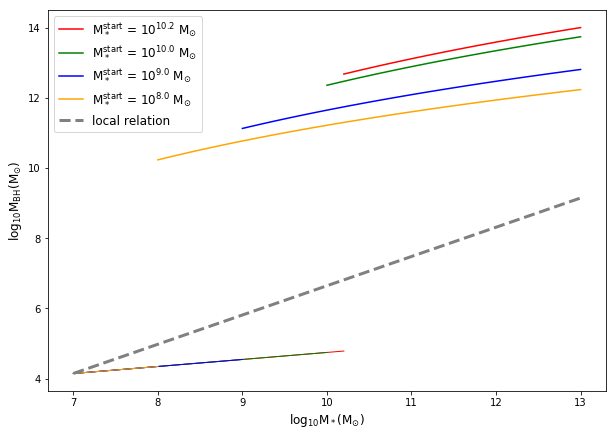

In [474]:
def logrith(x, base, norm, scale):
    
    return (np.log((x-x[0]+1)) / np.log(base))*scale + norm

fig = plt.figure(figsize=(10,7))
colors = ['r','g','b','orange']
dM = [0.1,0.3,1.3,2.3,3.3]

start = [7., np.log10(1.4*10**4.)]
stop = [13., np.log10(1.4*10**9.)]

qlf = QLF(1.5, 0.01)
qlf.get_dNdlnMstar(0.7)

for dm, c in zip(dM, colors):
    
    qlf.get_SMBM(dm)
    massc = qlf.mass_cuts
    slopes = qlf.slope_list
    ints = qlf.int_list
    
    m = slopes[2]
    b = ints[2]
    N = massc[0]*slopes[1]+ints[1]
    B = massc[0]
    x = np.linspace(massc[0], stop[0], 50)
    yscale1 = logrith(x, B, N, 1)
    scale = (stop[1] - N) / (np.log(x[-1]-x[0]+1) / np.log(B))
    y = logrith(x, massc[0] ,massc[0]*slopes[1]+ints[1], scale)
    plt.plot([start[0], massc[0]], [start[1], (massc[0]*slopes[0]+ints[0])],c=c,lw=1)
    plt.plot(x,y,c=c,label=r'M$_*^{\rm{start}}$ = $10^{'+str(massc[0])[:4]+'}$ M$_{\odot}$', lw=1.5)
    
plt.plot([start[0], stop[0]], [start[1], stop[1]],c='gray',lw=3,ls='dashed',label='local relation')
plt.xlabel(r'$\log_{10} \rmM_* (\rmM_{\odot})$',fontsize=12)
plt.ylabel(r'$\log_{10} \rmM_{\rmBH} (\rmM_{\odot})$',fontsize=12)
# plt.axis([start[0]-.2,stop[0] + .2,start[1]-.2,stop[1]+.2])


plt.legend(fontsize=12, loc='upper left')
# plt.savefig('plots/general-plots/logrith_cont_postdisk.pdf')


0.6043771683415984 11.72473606898169
0.630752023785492 9.45284624701935
0.723064017839119 7.113956367662503
0.7784512142712952 6.024885607558811
0.815376011892746 5.266217609083206


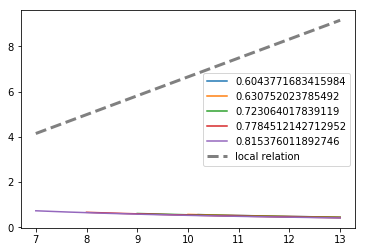

In [606]:
def logrith(x, B, N, yscale, xscale):
    return (np.log((x-x[0])*xscale+1) / np.log(B)) + N

start = [7., np.log10(1.4*10**4.)]
stop = [13., np.log10(1.4*10**9.)]

qlf = QLF(1.5, 0.01)
qlf.get_dNdlnMstar(0.7)
dM = [0.1,0.3,1.3,2.3,3.3]


for dm in dM:
    qlf.get_SMBM(dm)
    massc = qlf.mass_cuts
    slopes = qlf.slope_list
    ints = qlf.int_list
    
    x = np.linspace(massc[0],stop[0],200)
    B = massc[0]
    xscale = (stop[1]-massc[0]+ints[0])/(stop[0]-massc[0])
    yscale = (stop[1] - N) / (np.log((x[-1]-x[0])*xscale+1) / np.log(B))
    N = massc[0]*slopes[0]+ints[0]
    y = logrith(x, B, N, xscale, yscale)
    print(xscale, yscale)
    plt.plot(x, y, label=xscale)
plt.plot([start[0], stop[0]], [start[1], stop[1]],c='gray',lw=3,ls='dashed',label='local relation')
plt.legend()

2.0000000000000004
0.7736804391673658
2.0000000000000004
0.7822911644126793
2.0000000000000004
0.8696400062795873
1.9999999999999996
1.055614583867073


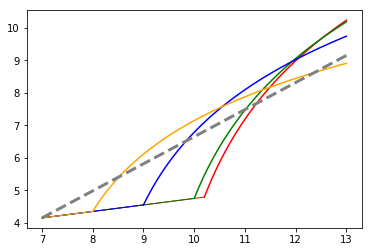

In [995]:
def logrith(xv, B):
    v = xv - x[0]
    return (np.log((v)+1) / np.log(B))

colors = ['r','g','b','orange']

qlf = QLF(1.5, 0.01)
qlf.get_dNdlnMstar(0.7)
dM = [0.1,0.3,1.3,2.3,3.3]

for dm,c in zip(dM,colors):
    qlf.get_SMBM(dm)
    massc = qlf.mass_cuts
    slopes = qlf.slope_list
    ints = qlf.int_list
    sp = stop[0]-1.65*dm#stop[0]
    
    x = np.linspace(massc[0],stop[0],100)
    base = np.e**(.5/(sp-x[0]))
    N = massc[0]*slopes[0]+ints[0]
    m = 1/((sp-x[0])*np.log(base))
    print(m)
    yl = logrith(x, base) + N
    scale = stop[1]/max(yl)
    print(scale)
    y = yl*scale - N*scale + N
    plt.plot(x, y, c=c)
    plt.plot([start[0], massc[0]], [start[1], (massc[0]*slopes[0]+ints[0])],lw=1,c=c)
#     plt.plot(x, x * m + b)
plt.plot([start[0], stop[0]], [start[1], stop[1]],c='gray',lw=3,ls='dashed',label='local relation')

Implementing Sarah's continous post-disk relation which worked a lot better than mine. 

We also figured out an issue for when we dont have a local slope of 1 but found an approximate solution. ---->

|

|

|

V

Text(0.5,1,'local relation Haring+Rix 2004')

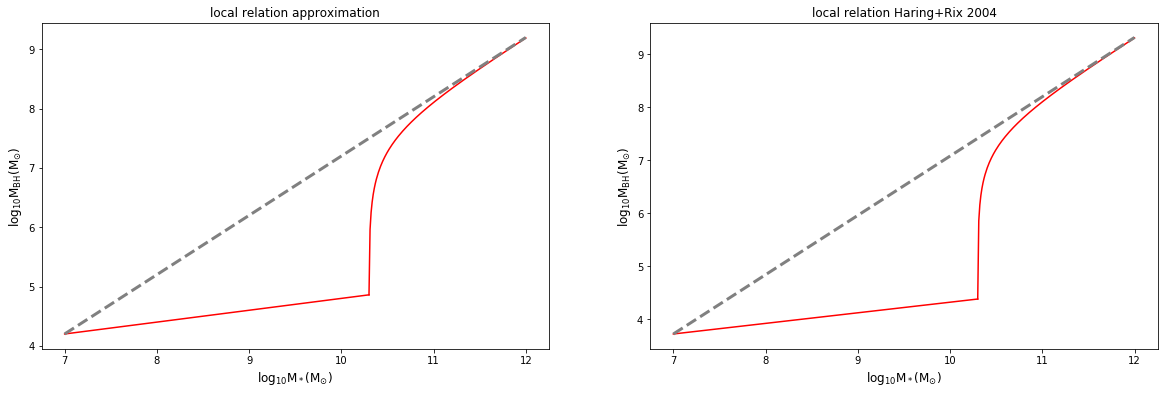

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,6))

norm = [11, 8.2]

approx = [1, norm[1] - norm[0]]
start_approx = [7., 7.*approx[0]+approx[1]]
early_approx = [0.2, start_approx[1] - start_approx[0] * 0.2]

local = [1.12, norm[1] - 1.12*norm[0]]
start_local = [7., 7.*local[0]+local[1]]
early_local = [0.2, start_local[1] - start_local[0] * 0.2]

def logMbh(Ms, Ms0, approx_local = False):
    if approx_local == False:
        Mbh0 = Ms0 * early_local[0] + early_local[1]
        beta = local[0]
        alpha = 10**norm[1] / 10**(norm[0]*beta)
    
    else:
        Mbh0 = Ms0 * early_approx[0] + early_approx[1]
        beta = approx[0]        
        alpha = 10**norm[1] / 10**(norm[0]*beta)
#     print('local_approx = ',approx_local,'\n \n Ms0 = ',Ms0,'\n \n alpha = ',alpha,'\n \n slopes = ',beta*alpha*(10**Ms)**beta/(10**Mbh0 + alpha*10**(Ms*(beta-1))*(10**Ms - 10**Ms0)))
    return np.log10(10**Mbh0 + alpha*10**(Ms*(beta-1))*(10**Ms - 10**Ms0))
    
    
    
colors = ['r','g','b','purple']
Mstar0 = 9
for Mstar0, c in zip([10.3],colors):#[11,10,9,8]
    xpre = np.linspace(7,Mstar0,150)
    xpos = np.linspace(Mstar0,12,150)
    
    ypos = logMbh(xpos, Mstar0, approx_local = False)
    ypre = xpre * early_local[0] + early_local[1] 
    
    yposa = logMbh(xpos, Mstar0, approx_local = True)
    yprea = xpre * early_approx[0] + early_approx[1]
    
    ax1.plot(xpos, yposa, c=c)
    ax1.plot(xpre, yprea, c=c)
    
    ax2.plot(xpos, ypos, c=c)
    ax2.plot(xpre, ypre, c=c)
    
Mstot = np.linspace(7,12,200)
ax1.plot(Mstot, Mstot * approx[0] + approx[1],c='grey',ls='dashed',lw=3)
ax2.plot(Mstot, Mstot * local[0] + local[1],c='gray',lw=3,ls='dashed')

ax1.set_xlabel(r'$\log_{10} \rmM_* (\rmM_{\odot})$',fontsize=12)
ax1.set_ylabel(r'$\log_{10} \rmM_{\rmBH} (\rmM_{\odot})$',fontsize=12)
ax1.set_title('local relation approximation')
ax2.set_xlabel(r'$\log_{10} \rmM_* (\rmM_{\odot})$',fontsize=12)
ax2.set_ylabel(r'$\log_{10} \rmM_{\rmBH} (\rmM_{\odot})$',fontsize=12)
ax2.set_title('local relation Haring+Rix 2004')

# plt.savefig('plots/general-plots/cont_postdisk_1plot.pdf')

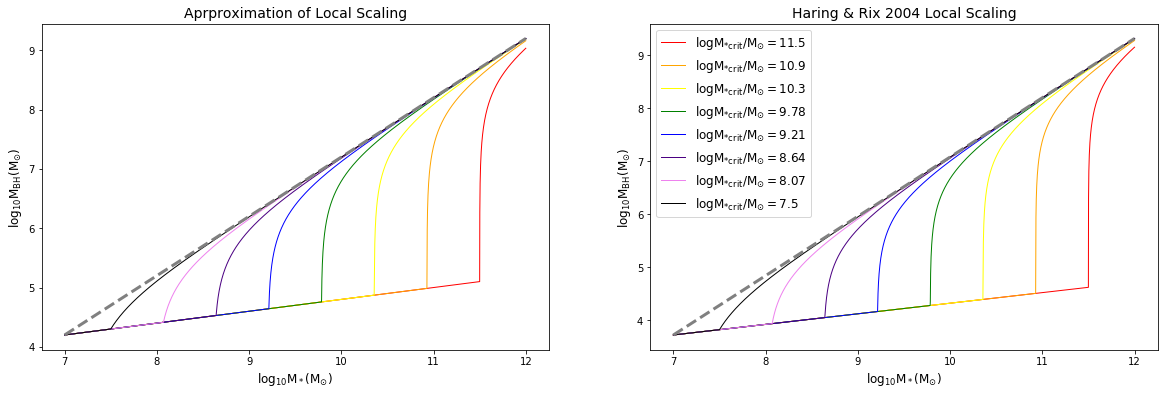

In [81]:
def get_Mbh(logMstar, logMstar0, approx_local = False):
    norm = [11, 8.2]
    
    logMbh = logMstar * 0
    slopes = logMstar * 0
    
    if approx_local == False:  
        post_params = [1.12, norm[1] - 1.12*norm[0]]
        init = [7., 7.*post_params[0]+post_params[1]]
        pre_params = [0.2, init[1] - init[0] * 0.2]
    
    else:
        post_params = [1, -2.8]
        init = [7., 7.*post_params[0]+post_params[1]]
        pre_params = [0.2, init[1] - init[0] * 0.2]
    
    post = (logMstar > logMstar0)
    pre = (logMstar <= logMstar0)
    Ms = 10**logMstar
    Ms0 = 10**logMstar0
    Mbh0 = 10**(logMstar0 * pre_params[0] + pre_params[1])
    beta = post_params[0]        
    alpha = 10**norm[1] / 10**(norm[0]*beta)
    
    Mbh = Mbh0 + alpha * Ms[post]**(beta-1) * (Ms[post] - Ms0)
    logMbh[post] = np.log10(Mbh)
    slopes[post] = np.gradient(logMbh[post],logMstar[post])
    
    logMbh[pre] = logMstar[pre] * pre_params[0] + pre_params[1]
    slopes[pre] = pre_params[0]
    return logMbh


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,6))

colors = ['r','orange','yellow','g','b','indigo','violet','black']
x = np.linspace(7,12,3000)
for i,c in zip(np.linspace(7.5,11.5,8)[::-1],colors):
    ax2.plot(x, get_Mbh(x, i), c=c, label=r'$\log\rmM_{* \rm{crit}}/\rmM_{\odot} = $'+str(i)[:4], lw = 1)
    ax1.plot(x, get_Mbh(x, i, approx_local=True),c=c, lw=1)
ax2.plot(x, x*1.12-4.12,c='gray',lw = 3, ls='dashed')
ax1.plot(x, x-2.8, ls='dashed', lw = 3, c='gray')
ax1.set_xlabel(r'$\log_{10} \rmM_* (\rmM_{\odot})$',fontsize=12)
ax1.set_ylabel(r'$\log_{10} \rmM_{\rmBH} (\rmM_{\odot})$',fontsize=12)
ax1.set_title('Aprproximation of Local Scaling',fontsize=14)
ax2.set_xlabel(r'$\log_{10} \rmM_* (\rmM_{\odot})$',fontsize=12)
ax2.set_ylabel(r'$\log_{10} \rmM_{\rmBH} (\rmM_{\odot})$',fontsize=12)
ax2.set_title('Haring & Rix 2004 Local Scaling', fontsize=14)
ax2.legend(fontsize = 12)
plt.savefig('plots/paper-plots/cont-postdisk-comparison.pdf')

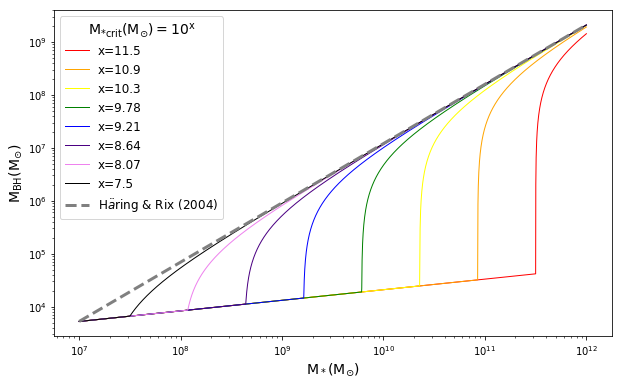

In [25]:
def get_Mbh(logMstar, logMstar0, approx_local = False):
    norm = [11, 8.2]
    
    logMbh = logMstar * 0
    slopes = logMstar * 0
    
    if approx_local == False:  
        post_params = [1.12, norm[1] - 1.12*norm[0]]
        init = [7., 7.*post_params[0]+post_params[1]]
        pre_params = [0.2, init[1] - init[0] * 0.2]
    
    else:
        post_params = [1, -2.8]
        init = [7., 7.*post_params[0]+post_params[1]]
        pre_params = [0.2, init[1] - init[0] * 0.2]
    
    post = (logMstar > logMstar0)
    pre = (logMstar <= logMstar0)
    Ms = 10**logMstar
    Ms0 = 10**logMstar0
    Mbh0 = 10**(logMstar0 * pre_params[0] + pre_params[1])
    beta = post_params[0]        
    alpha = 10**norm[1] / 10**(norm[0]*beta)
    
    Mbh = Mbh0 + alpha * Ms[post]**(beta-1) * (Ms[post] - Ms0)
    logMbh[post] = np.log10(Mbh)
    slopes[post] = np.gradient(logMbh[post],logMstar[post])
    
    logMbh[pre] = logMstar[pre] * pre_params[0] + pre_params[1]
    slopes[pre] = pre_params[0]
    return logMbh


fig, ax2 = plt.subplots(1, 1, figsize=(10,6))

colors = ['r','orange','yellow','g','b','indigo','violet','black']
x = np.linspace(7,12,3000)
for i,c in zip(np.linspace(7.5,11.5,8)[::-1],colors):
    ax2.plot(10**x, 10**get_Mbh(x, i), c=c, label='x='+str(i)[:4], lw = 1)
ax2.plot(10**x, 10**(x*1.12-4.12),c='gray',lw = 3, ls='dashed', label = r'H$\"{a}$ring & Rix (2004)')
ax2.set_xlabel(r'$\rmM_* (\rmM_{\odot})$',fontsize=14)
ax2.set_ylabel(r'$\rmM_{\rmBH} (\rmM_{\odot})$',fontsize=14)
ax2.set_xscale('log')
ax2.set_yscale('log')
legend = ax2.legend(title = r'$\rmM_{*\rm{crit}}(\rmM_{\odot}) = 10^x$',fontsize = 12)
plt.setp(legend.get_title(),fontsize=14)
plt.savefig('plots/paper-plots/cont-postdisk-comparison.pdf')

/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/font_manager.py:1328: UserWarning: findfont: Font family ['serif'] not found. Falling back to DejaVu Sans
  (prop.get_family(), self.defaultFamily[fontext]))


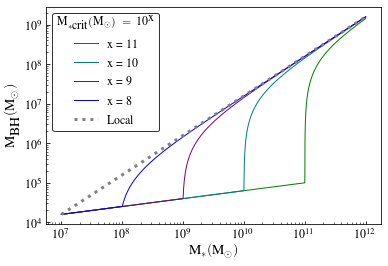

In [61]:
def get_Mbh(logMstar, logMstar0, approx_local = True):
    norm = [11, 8.2]
    
    logMbh = logMstar * 0
    slopes = logMstar * 0
    
    if approx_local == False:  
        post_params = [1.12, norm[1] - 1.12*norm[0]]
        init = [7., 7.*post_params[0]+post_params[1]]
        pre_params = [0.2, init[1] - init[0] * 0.2]
    
    else:
        post_params = [1, -2.8]
        init = [7., 7.*post_params[0]+post_params[1]]
        pre_params = [0.2, init[1] - init[0] * 0.2]
    
    post = (logMstar > logMstar0)
    pre = (logMstar <= logMstar0)
    Ms = 10**logMstar
    Ms0 = 10**logMstar0
    Mbh0 = 10**(logMstar0 * pre_params[0] + pre_params[1])
    beta = post_params[0]        
    alpha = 10**norm[1] / 10**(norm[0]*beta)
    
    Mbh = Mbh0 + alpha * Ms[post]**(beta-1) * (Ms[post] - Ms0)
    logMbh[post] = np.log10(Mbh)
    slopes[post] = np.gradient(logMbh[post],logMstar[post])
    
    logMbh[pre] = logMstar[pre] * pre_params[0] + pre_params[1]
    slopes[pre] = pre_params[0]
    return logMbh

from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)


fig, ax2 = plt.subplots(1, 1, figsize=(6,4))

colors = ['green','teal','purple','b','indigo','black']
x = np.linspace(7,12,3000)
for i,c in zip([8,9,10,11][::-1],colors):
    ax2.plot(10**x, 10**get_Mbh(x, i), c=c, label='x\ =\ '+str(i)[:4], lw = 1)
ax2.plot(10**x, 10**(x-2.8),c='gray',lw = 3, ls='dotted', label = '~Local')
ax2.set_xlabel(r'M$_* ($M$_{\odot})$',fontsize=14)
ax2.set_ylabel(r'M$_{\textnormal{BH}} ($M$_{\odot})$',fontsize=14)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.tick_params(axis='both', which='both', labelsize=12, direction='in')
legend = ax2.legend(title = r'M$_{*{\textnormal{crit}}}($M$_{\odot})\ =\ 10^\textnormal{x}$', fontsize=12)
plt.setp(legend.get_title(), fontsize=12)
legend.get_frame().set_edgecolor('k')
plt.savefig('plots/paper-plots/cont-postdisk-comparison_approxlocal.pdf')


$\dot{M}_{BH} = \alpha \dot{M}_* ^\beta$

$ M_{BH}d\log M_{BH} = \alpha \left( M_*d\log M_*\right)^\beta  $

$d\log M_{BH} = \frac{\alpha}{M_{BH}} M_{*}^{\beta} \left( d\log M_{*} \right)^{\beta}$

Using a Monte Carlo sampling method to determine the error on the Shen+ fits due to the uncertainties presented in the fit parameters.

We could approximate the error as the same on both sides by at max theres like a 0.06 different in the sigma values so it is probably best to just use the top and bottom ones seperately.

Also made some plots showing the errors with their functions.---->

|

|

|

V

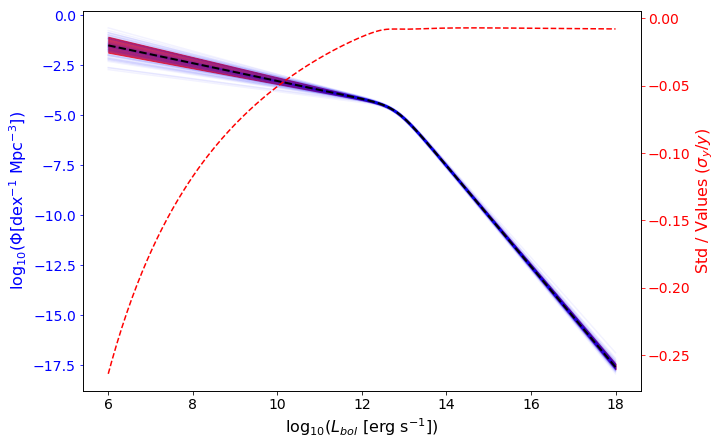

In [123]:
import numpy as np
import scipy as sp
import scipy.stats
import matplotlib.pyplot as plt

lums = np.linspace(6,18,300)
params = {'a0':[0.85858, 0.03092, 0.02876], 'a1':[-0.26236, 0.02003, 0.01753], 'a2':[0.02105, 0.00136, 0.00113],\
        'b0':[2.54992, 0.01915, 0.02949], 'b1':[-1.04735, 0.01815, 0.02999], 'b2':[1.13277, 0.01988, 0.03891],\
        'c0':[13.01297, 0.00943, 0.01354], 'c1':[-0.57587, 0.00205, 0.00261], 'c2':[0.45361, 0.00290, 0.00434],\
        'd0':[-3.53138, 0.02694, 0.02690], 'd1':[-0.39961, 0.00871, 0.00896]}
param_list = np.array([params[i] for i in params])

NUM = int(1e4)
SKIP = 100

def get_params():
    rand_params = np.zeros((NUM, len(params)))
    ind = 0
    for p in params:
        i = np.random.randint(1,3,NUM)
        rand_params[:,ind][i == 1] = param_list[ind][0] + np.abs(np.random.normal(0, param_list[ind][1], size = len(i[i==1])))
        rand_params[:,ind][i == 2] = param_list[ind][0] - np.abs(np.random.normal(0, param_list[ind][2], size = len(i[i==2])))
        ind += 1
    return rand_params
    
rand_params = get_params()

        
###    b0 * 2      c0 * 2
def shen_fit(p, z):
    L = lums
    a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
    zr = 2.0
    zfrac = (1 + z)/(1 + zr)
    g1 = C.chebval(1 + z, [a0, a1, a2])
    g2 = 2*b0/(zfrac**b1 + zfrac **b2)
    logLs = 2*c0/(zfrac**c1 + zfrac**c2)
    logPhis = C.chebval(z, [d0]) + C.chebval(1 + z, [0, d1])
    Lfrac = 10**L / 10**logLs
    Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)
    
    return np.log10(Phibol)

ys = np.apply_along_axis(shen_fit, 1, rand_params, 1.5).T
ya = shen_fit(param_list[:,0], 1.5)

fracs = sp.stats.norm.cdf([-2, -1, 0, 1, 2])
percs = np.percentile(ys, 100*fracs, axis=1)

fig, ax = plt.subplots(figsize=(10,7))
ax.tick_params(axis='x', which='both', colors='k', labelsize=14)
ax.tick_params(axis='y', which='both', colors='b', labelsize=14)
ax.set_xlabel('$\log_{10}(L_{bol}$ [erg s$^{-1}])$',fontsize=16)
ax.set_ylabel('$\log_{10}(\Phi $[dex$^{-1}$ Mpc$^{-3}$])',fontsize=16,color='b')


ax.plot(lums, ys[:,::SKIP], 'b-', alpha = 0.05)
ax.fill_between(lums, percs[1, :], percs[3, :], color='r', alpha=.75)
ax.plot(lums, ya, 'k--',lw=2)

std = np.std(ys, axis=1)

tw = ax.twinx()
tw.plot(lums, std/ya, 'r--')
tw.tick_params(axis='y', which='both', colors='r', labelsize=14)
tw.set_ylabel('Std / Values ($\sigma_y/y$)', fontsize=16, color='r')

blw = ya-percs[1,:] ###std blw
abv = percs[3,:]-ya ###std abv
#print(max(np.abs(abv-blw)))
# print(std, '\n \n \n ', std-blw, '\n \n \n ', std-abv)


In [184]:
import numpy as np
import scipy as sp
import scipy.stats

def Shen_fit_uncer(z, lums):
    
    def get_params():
        rand_params = np.zeros((NUM, len(params)))
        ind = 0
        for p in params:
            i = np.random.randint(1,3,NUM)
            rand_params[:,ind][i == 1] = param_list[ind][0] + np.abs(np.random.normal(0, param_list[ind][1], size = len(i[i==1])))
            rand_params[:,ind][i == 2] = param_list[ind][0] - np.abs(np.random.normal(0, param_list[ind][2], size = len(i[i==2])))
            ind += 1
        return rand_params
    
    def shen_func(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(z, [d0]) + C.chebval(1 + z, [0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    params = {'a0':[0.85858, 0.03092, 0.02876], 'a1':[-0.26236, 0.02003, 0.01753], 'a2':[0.02105, 0.00136, 0.00113],\
        'b0':[2.54992, 0.01915, 0.02949], 'b1':[-1.04735, 0.01815, 0.02999], 'b2':[1.13277, 0.01988, 0.03891],\
        'c0':[13.01297, 0.00943, 0.01354], 'c1':[-0.57587, 0.00205, 0.00261], 'c2':[0.45361, 0.00290, 0.00434],\
        'd0':[-3.53138, 0.02694, 0.02690], 'd1':[-0.39961, 0.00871, 0.00896]}
    param_list = np.array([params[i] for i in params])
    
    NUM = int(1e4)
    
    rand_params = get_params()
    ys = np.apply_along_axis(shen_func, 1, rand_params).T
    ya = shen_func(param_list[:,0])
    
    fracs = sp.stats.norm.cdf([-2, -1, 0, 1, 2])
    percs = np.percentile(ys, 100*fracs, axis=1)
    
    std_ave = np.std(ys, axis=1)
    std_blw = ya-percs[1,:]
    std_abv = percs[3,:]-ya
    
    return ya, std_ave, std_abv, std_blw

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1,4,figsize=(22,4))
for ax, z in zip([ax1, ax2, ax3, ax4], [0.2, 1.2, 4.2, 6.0]):
    lum = np.linspace(6,18,100)
    y, ave, abv, blw = Shen_fit_uncer(z, lum)
    ax.plot(lum,y,color='k',label='Shen+ QLF: z = '+str(z))
    ax.fill_between(lum,y+abv,y-blw,color='r',alpha=.5, label='Fit Uncertainty')
    ax.set_xlabel('$\log_{10}(L_{bol}/L_{\odot})$',fontsize=12)
    ax.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$',fontsize=12)
    ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/general-plots/Shen_QLF_uncertainty.pdf')

FigureCanvasNbAgg()

Time to go through the long process of converting the studies they used to actual ranges so I can kill myself before this is done. ---->

|

|

|

V

In [103]:
# This gives luminosity in given band given the bolometric luminosity.
# This is calculated from the mean AGN spectrum before obscuration.
#
# From Shen+ (in prep.)
def B_lum(mag):
    return (10**((mag - 34.1) / (-2.5)) ) * 1e7 * 3e10 / 4344e-8 ### L_f * c / lambda

def UV_lum(mag):
    return (10**((mag -34.1) / (-2.5))) * 1e7 * 3e10 / 1450e-8


def Shen_Lband(band, Lbol):
# Parameters of the bolometric correction fit depend on band.
    Lsun = 3.8e33
    if band=='B':
    # B-band
        c1 = 3.759
        k1 = -0.361
        c2 = 9.830
        k2 = -0.0063
        
    elif band=='UV':
    # UV (1450 A)
        c1 = 1.862
        k1 = -0.361
        c2 = 4.870
        k2 = -0.0063
        
    elif band=='midIR':
    # mid-IR (15 um)
        c1 = 4.361
        k1 = -0.361
        c2 = 11.40
        k2 = -0.0063
        
    elif band=='softX':
    # soft X-rays (0.5-2 keV)
        c1 = 5.712
        k1 = -0.026
        c2 = 17.67
        k2 = 0.278
        
    elif band=='hardX':
    # hard X-rays (2-10 keV)
        c1 = 4.073
        k1 = -0.026
        c2 = 12.60
        k2 = 0.278
        
    # This is Lbol/Lband.
    Lpiv = 10.**10.*Lsun # pivot luminosity for the fit
    # Normalized Lbol to simplify eqs below.
    L = Lbol/Lpiv
    A = c1*(L**k1)
    B = c2*(L**k2)
    Lbol_Lband = A+B
    Lband_ = Lbol/Lbol_Lband
    # Also calculate dlog(Lbol)/dlog(Lband), since this uses the same
    # fit parameters.
    dlogLbol_dlogLband = (A + B)/((1.-k1)*A + (1.-k2)*B)
    return (Lband_, dlogLbol_dlogLband)

B = {'kennefick+1995':{},'schmidt1995':{},'croom+2004':{}}

UV = {'fan+2001a':{},'fan+2001b,2003,2004':{},'wolf+2003':{},\
      'christiani+2004':{},'hunt+2004':{},\
      'siana+2006':{},'fontanot+2007':{},'siana+2008':{},'croom+2009':{},\
      'willot+2010':{},'glikman+2011':{},'ikeda+2012':{},'masters+2012':{},'shen&kelly2012':{},\
      'mcgreer+2013':{},'ross+2013':{},'giallongo+2015':{},\
      'kashikawa+2015':{},'jiang+2016':{},'palanque-delabrouille+2016':{},'yang+2016':{},\
      'akiyama+2018':{},'matsuoka+2018':{},'mcgreer+2018':{},'wang+2018a':{},'yang+2018':{}}

soft_xray = {'miyaji+2000,2001':{},'hasinger+2005':{},'silverman+2005':{},'ebrero+2009':{}}

hard_xray = {'ueda+2003':{},'lafranca+2005':{},\
            'aird+2008':{},'ebrero+2009':{},\
            'aird+2010':{},'fiore+2012':{},'ueda+2014':{},'aird+2015a':{},'miyaji+2015':{},\
            'khorunzhev+2018':{}}

IR = {'matute+2006':{}}

#######

B_z =[[4.0,4.5],[3.5,4.5],[0.4,2.1]]

UV_z = [[3.6,5.0],[5.7,6.4],[1.2,4.8],[4,5.2],[2,4],\
        [2.8,3.4],[3.5,5.2],[2.83,3.44],[0.4,2.6],[5.75,6.45],\
        [3.8,5.2],[5.07,5.07],[3.1,5.0],[0.3,5],[4.7,5.1],[2.2,3.5],\
        [2.2,3.5],[4,6.5],[5.85,6.45],[5.7,6.4],[4.7,5.4],[3.6,4.3],[5.7,6.5],\
        [4.7,5.4],[6.45,7.05],[0.5,4.5]]

soft_xray_z = [[0.015,4.8],[0.015,4.8],[0.1,5],[0.01,3]]

hard_xray_z = [[0.015,3.0],[0.0,4.0],[2.5,3.5],[0.01,3],\
               [0,3.5],[3,7.5],[0,5],[0,7],[0.015,5.8],[3.0,5.1]]

IR_z = [[0.1,1.2]]

#######

B_L = [[-28.5,-26.5],[-27.5,-25.5],[-28.5,-20.5]] ##AB mag

UV_L = [[-27.5,-25.5],[-28,-26.5],[-28.5,-23.5],[-23.5,-21],[-27,-21],[-26.5,-23.5],[-26.5,-23.5],\
        [-28,-21],[-26.11,-23.61],[-29.75,-20.25],[-27.63,-25.1],[-26.05,-22.15],\
        [-28.45,-21.61],[-23.52,-22.52],[-24.5,-21],[-29.25,-22.65],[-27.98, -24.18],\
        [-27.53,-23],[-28.42,-23.59],[-22.5,-19.0],[-22.84,-22.84],[-29,-26.8],[-25.88,-21.88],\
        [-30,-22],[-26.35,-22.9],[-27.6,-25.5],[-27,-20.5]] ##AB mag

soft_xray_L = [[41,47],[42,48],[44.5,46],[40.5,46.81]] ##10^X erg/s

hard_xray_L = [[41.5,46.5],[42,46.5],[43,44.5],[42.5,48],[41.83,45.87],[41.3,45.8],[42.75,44.5],\
               [42.75,44.5],[38.25,47.5],[42,46],[45,np.log10(7.5*10**45)]]

IR_L = [[42,47]]

######

B_N = [10,8,20905]

UV_N = [39,9,192,4,11,100,130,13,100,10637,19,338,1,128,58000,162,22301,5476,22,2,52,13876,99,\
        1666,110,25,17,109]

soft_xray_N = [691,2566,217,1009]

hard_xray_N = [247,508,15,368,435,np.nan, 40,4039,7308,3200,101]

IR_N = [148]

######

B_params = [B_z, B_L, B_N, 'B']
UV_params = [UV_z, UV_L, UV_N, 'UV']
soft_xray_params = [soft_xray_z, soft_xray_L, soft_xray_N, 'softX']
hard_xray_params = [hard_xray_z, hard_xray_L, hard_xray_N, 'hardX']
IR_params = [IR_z, IR_L, IR_N, 'midIR']

bands = [B, UV, soft_xray, hard_xray, IR]
params = [B_params, UV_params, soft_xray_params, hard_xray_params, IR_params]

# bands = [soft_xray, hard_xray, IR]
# params = [soft_xray_params, hard_xray_params, IR_params]

for band, param in zip(bands, params):
    for i, z, L, N in zip(band, param[0], param[1], param[2]):
        band[i]['redshift range'] = z
        if param[3] == 'B':
            band[i]['luminosity range'] = [np.log10(B_lum(mag)) for mag in L][::-1]
        elif param[3] == 'UV':
            band[i]['luminosity range'] = [np.log10(UV_lum(mag)) for mag in L][::-1]
        else:
            band[i]['luminosity range'] = L
        band[i]['band'] = param[3]
        band[i]['number of AGN'] = N
        print(band[i])

{'redshift range': [4.0, 4.5], 'luminosity range': [46.079231438138876, 46.87923143813887], 'band': 'B', 'number of AGN': 10}
{'redshift range': [3.5, 4.5], 'luminosity range': [45.67923143813887, 46.479231438138875], 'band': 'B', 'number of AGN': 8}
{'redshift range': [0.4, 2.1], 'luminosity range': [43.67923143813887, 46.87923143813887], 'band': 'B', 'number of AGN': 20905}
{'redshift range': [3.6, 5.0], 'luminosity range': [46.155753252484686, 46.95575325248469], 'band': 'UV', 'number of AGN': 39}
{'redshift range': [5.7, 6.4], 'luminosity range': [46.55575325248469, 47.155753252484686], 'band': 'UV', 'number of AGN': 9}
{'redshift range': [1.2, 4.8], 'luminosity range': [45.35575325248469, 47.35575325248469], 'band': 'UV', 'number of AGN': 192}
{'redshift range': [4, 5.2], 'luminosity range': [44.35575325248469, 45.35575325248469], 'band': 'UV', 'number of AGN': 4}
{'redshift range': [2, 4], 'luminosity range': [44.35575325248469, 46.75575325248469], 'band': 'UV', 'number of AGN': 

In [27]:
print(ergs_AB(-21))
Shen_Lband('B',10**np.linspace(43,48,20))

4.7321238410854854e+42


(array([6.25014996e+41, 1.24135312e+42, 2.44040511e+42, 4.75269685e+42,
        9.17745576e+42, 1.75881247e+43, 3.34842826e+43, 6.33837711e+43,
        1.19396986e+44, 2.23982580e+44, 4.18726191e+44, 7.80535258e+44,
        1.45149977e+45, 2.69392850e+45, 4.99175293e+45, 9.23731395e+45,
        1.70753514e+46, 3.15363922e+46, 5.82028487e+46, 1.07355621e+47]),
 array([0.87624343, 0.88985198, 0.90289634, 0.91513293, 0.92638154,
        0.936531  , 0.94553583, 0.95340659, 0.96019672, 0.96598879,
        0.97088211, 0.97498257, 0.97839523, 0.98121935, 0.98354544,
        0.98545389, 0.98701471, 0.9882879 , 0.98932426, 0.99016638]))

In [118]:
%matplotlib widget
Lbol = 10**np.linspace(37,53,10)
for band in bands:
    for i in band:
        Lband = np.log10(Shen_Lband(band[i]['band'], Lbol)[0])
        Lblw = band[i]['luminosity range'][0]
        Labv = band[i]['luminosity range'][1]
        minL = Lbol[np.argmin(np.abs(Lband - Lblw))]
        maxL = Lbol[np.argmin(np.abs(Lband - Labv))]
        zmin = band[i]['redshift range'][0]
        zmax = band[i]['redshift range'][1]
        plt.fill_between([zmin, zmax],[minL, minL],[maxL, maxL], alpha = 0.15, color='r')
plt.axis([0,8,1e37,1e53])
plt.yscale('log')
plt.xlabel('Redshift (z)')
plt.ylabel('AGN Bolometric Luminosiy (erg/s)')
print(np.log10(10**42.5/3.8e33),np.log10(10**48.5/3.8e33))
plt.savefig('plots/general-plots/fit_luminosity_range.pdf')

FigureCanvasNbAgg()

8.92021640338319 14.92021640338319


Creating code for generating chi2 grids ------>

|

|

|

|

|

v

In [68]:
from functions_postdisk import *
import h5py
import itertools
import numpy as np
import scipy as sp
import scipy.stats
from numpy.polynomial import chebyshev as C

zlist = [0.2, 0.4, 0.8, 1.2, 1.8, 2.4, 3.0, 3.6, 4.2, 4.8, 5.4, 6.0]
reso = 5
qlf_bins = 0.005
sig_lnMstar = 0.7
logMstar0 = np.linspace(7,12,reso)
xsigpre = np.linspace(1.0,8.0,reso)
xsigpost = np.linspace(1.0,8.0,reso)

f = h5py.File("chi2_3pShenfit_nm.h5py", "w")

f.attrs.modify('resolution', reso)
dset = f.create_dataset('logMstar0', data = logMstar0)
dset = f.create_dataset('siglnX2', data = xsigpost)
dset = f.create_dataset('siglnX1', data = xsigpre)

f.close()

def chi2(a, z, qlf):
    logMstar0 = a[0]
    sig_lnX = [a[1], a[2]]
    qlf.get_Mbh(logMstar0)
    qlf.get_dNdlnL(lums, sig_lnX)
    qlf.get_Mbh(logMstar0, approx_local=False)

    ym = np.log10(qlf.dNdlnL * np.log(10))

    return np.sum((ym-ya)**2)

for z in zlist:
    qlf = QLF(z, qlf_bins)
    qlf.get_dNdlnMstar(sig_lnMstar)
    xo, yo, yerro = grab_obs(z)
    lums = np.linspace(8.95, 14.95, 150)
    
    ya, err_ave, err_abv, err_blw = Shen_fit_uncer(z, lums)

    combos = np.array(list(itertools.product(logMstar0, xsigpre, xsigpost)))
    chi23d = np.apply_along_axis(chi2, 1, combos, z, qlf).reshape(reso, reso, reso)

    f = h5py.File("chi2_3pShenfit_nm.h5py", "a")
    
    grp = f.create_group("z="+str(z))
    dset = grp.create_dataset('chi23d_grid', data = chi23d)
    
    f.close()

/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions_postdisk.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
